# 10 · A coupled powertrain point, written entirely by hand

Part 2 looked at components one at a time. Now couple six of them into one operating point of a series-hybrid powertrain: a
turboshaft drives a generator; the generator and a battery feed a bus; a motor on the bus drives a rotor through a gearbox. Every
connection is written by hand, as in `examples/series_hybrid_point_explicit.py`, the simplest coupled case the repository keeps
(rule 10). Tutorial 11 builds the same point from a network description. The flight point (tutorial 15) is the production version.

The point of doing it by hand: you see exactly which quantities are **unknowns**, which relations are **equations**, how
many degrees of freedom remain, and what the optimizer is free to choose. Every later problem in the series is this one, scaled up.

**In this notebook**
1. The network and its physics, component by component.
2. Unknowns, equations and degrees of freedom.
3. The Opti problem, line by line.
4. Reading the solution: power flow from fuel to thrust.
5. Freeing the energy split: the optimizer chooses the battery share.
6. Where the same couplings live in the production flight point.

**Run time:** a few seconds.

In [1]:
from tutorial_helpers import *
import numpy as onp
from aircraft_closure.powertrain.components.motor import Motor
from aircraft_closure.powertrain.components.generator import Generator
from aircraft_closure.powertrain.components.battery import Battery
from aircraft_closure.powertrain.components.turboshaft import SimpleTurboshaft
from aircraft_closure.powertrain.components.gearbox import Gearbox
from aircraft_closure.powertrain.components.propulsor import ActuatorDiskPropulsor

## 1. The network

```
 fuel ──► turboshaft ──shaft──► generator ──┐
                                            ├── DC bus (one voltage) ──► motor ──shaft──► gearbox ──shaft──► rotor ──► thrust
                              battery ──────┘
```

The components are the defaults of each class (one illustrative installation, not the Halo): a 100 kW motor, a generator, a 36 MJ
battery at 800 V open circuit, a 150 kW turboshaft, a 4:1 gearbox, a 10 m² actuator-disk rotor. The point is a hover at sea level
with 5,000 N of thrust.

In [2]:
motor_c, generator_c, battery_c = Motor(), Generator(), Battery()
engine_c, gear_c, rotor_c = SimpleTurboshaft(), Gearbox(), ActuatorDiskPropulsor()
for c in (motor_c, generator_c, battery_c, engine_c, gear_c, rotor_c):
    print(f"{type(c).__name__:<24} mass {c.get_mass():6.1f} kg   limits {c.get_limits()}")

Motor                    mass   20.0 kg   limits MotorLimits(power_rated_W=100000.0, max_speed_rad_s=1000.0, max_torque_Nm=500.0, min_voltage_V=400.0, max_voltage_V=900.0)
Generator                mass   25.0 kg   limits MotorLimits(power_rated_W=100000.0, max_speed_rad_s=1000.0, max_torque_Nm=500.0, min_voltage_V=400.0, max_voltage_V=900.0)
Battery                  mass   40.0 kg   limits BatteryLimits(max_discharge_power_W=100000.0, max_charge_power_W=50000.0, min_soc=0.2, max_soc=0.95)
SimpleTurboshaft         mass   75.0 kg   limits TurboshaftLimits(power_rated_W=150000.0)
Gearbox                  mass   10.0 kg   limits GearboxLimits(power_rated_W=100000.0)
ActuatorDiskPropulsor    mass   30.0 kg   limits PropulsorLimits(max_shaft_power_W=100000.0)


## 2. Unknowns, equations and degrees of freedom

Fix two speeds by assumption, as the example does: the motor turns at 400 rad/s and the generator at 400 rad/s (its peak-efficiency
speed). The remaining unknowns at the point:

| Unknown | Symbol |
|---|---|
| motor torque | $Q_m$ |
| generator torque | $Q_g$ |
| battery current | $I_b$ |
| rotor induced velocity | $v_i$ (power mode of the actuator disk, tutorial 08) |

The equations (every other quantity is an explicit function of these):

| Equation | Physics |
|---|---|
| $P_\text{rotor} - T(v_i)\,v_i/\mathrm{FM} = 0$ | momentum theory: the rotor absorbs the gearbox output power |
| $T(v_i) = 5000$ N | the thrust required |
| $P_b = h\,P_{e,m}$ | the battery supplies a share $h$ of the motor's electrical power |
| $P_{e,g} + P_b = P_{e,m}$ | bus power balance |

Four unknowns, four equations: a **square system** at fixed $h$. With $h$ free there is one degree of freedom, so the problem needs an
objective (section 5). Note the couplings: the bus voltage is the battery's terminal voltage, which depends on its current; the motor's
current depends on that voltage; the generator's output also depends on it. The four equations are solved simultaneously.

## 3. The Opti problem, line by line

In [3]:
def hover_point(hybridization_electric=0.2, thrust_N=5000.0, free_split=False):
    opti = asb.Opti()
    # ---- operating unknowns (prescribed speeds as in the reference example) ----
    speed_motor_rad_s = 400.0
    speed_generator_rad_s = 400.0
    torque_motor_Nm = opti.variable(init_guess=200, lower_bound=0)
    torque_generator_Nm = opti.variable(init_guess=200, lower_bound=0)
    current_battery_A = opti.variable(init_guess=20, lower_bound=0)
    induced_velocity_m_s = opti.variable(init_guess=10, lower_bound=0)
    if free_split:
        hybridization_electric = opti.variable(init_guess=0.2, lower_bound=0.0, upper_bound=1.0)

    # ---- component physics: each call returns expressions of the unknowns ----
    pack = battery_c.evaluate(current_battery_A, soc=0.9)
    voltage_bus_V = pack.voltage_V                                     # connection: the bus is at the battery's terminal voltage
    motor = motor_c.evaluate(speed_motor_rad_s, torque_motor_Nm, voltage_bus_V)
    generator = generator_c.evaluate(speed_generator_rad_s, torque_generator_Nm, voltage_bus_V)
    engine = engine_c.evaluate(generator.power_shaft_W)               # connection: engine shaft = generator shaft
    gear = gear_c.evaluate(speed_motor_rad_s, torque_motor_Nm)        # connection: motor shaft = gearbox input
    rotor = rotor_c.evaluate(0.0, asb.Atmosphere(altitude=0), shaft_power_W=gear.power_output_W,   # gearbox output = rotor shaft
                             induced_velocity_m_s=induced_velocity_m_s)

    # ---- the four equations ----
    opti.subject_to([
        rotor.power_residual_W == 0,                                                  # momentum theory
        rotor.thrust_N == thrust_N,                                                   # thrust required
        pack.power_electric_W == hybridization_electric * motor.power_electric_W,     # energy split
        generator.power_electric_W + pack.power_electric_W == motor.power_electric_W, # bus power balance
    ])
    # ---- limits, written as plain inequalities here (tutorial 11 replaces them by named margins) ----
    m, g, e, gb, rt, b = (c.get_limits() for c in (motor_c, generator_c, engine_c, gear_c, rotor_c, battery_c))
    opti.subject_to([
        motor.power_shaft_W <= m.power_rated_W, torque_motor_Nm <= m.max_torque_Nm,
        voltage_bus_V >= m.min_voltage_V, voltage_bus_V <= m.max_voltage_V,
        generator.power_shaft_W <= g.power_rated_W, torque_generator_Nm <= g.max_torque_Nm,
        generator.power_electric_W >= 0,
        engine.power_shaft_W <= e.power_rated_W,
        gear.power_input_W <= gb.power_rated_W,
        rotor.shaft_power_W <= rt.max_shaft_power_W,
        pack.power_electric_W <= b.max_discharge_power_W,
    ])
    if free_split:
        opti.minimize(engine.fuel_flow_kg_s * 1000)                  # one degree of freedom: choose it for minimum fuel flow
    solution = opti.solve(verbose=False)
    return opti, solution, dict(pack=pack, motor=motor, generator=generator, engine=engine, gear=gear, rotor=rotor,
                                voltage_bus_V=voltage_bus_V, hybridization_electric=hybridization_electric)

opti, s, x = hover_point()
print(describe_opti(opti))

{'variables': 4, 'constraints': 19, 'equalities': 4, 'inequalities': 15}


4 variables; 4 equalities; the inequalities are the 11 limits plus the 4 lower bounds on the variables. With no objective, IPOPT
just finds the point that satisfies everything (a feasibility problem).

## 4. Reading the solution

In [4]:
v = s.value
flow = [("fuel (chemical)", v(x["engine"].fuel_flow_kg_s) * engine_c.fuel_lower_heating_value_J_kg),
        ("turboshaft shaft", v(x["engine"].power_shaft_W)),
        ("generator electrical", v(x["generator"].power_electric_W)),
        ("battery terminal", v(x["pack"].power_electric_W)),
        ("motor electrical", v(x["motor"].power_electric_W)),
        ("motor shaft", v(x["motor"].power_shaft_W)),
        ("gearbox output = rotor shaft", v(x["gear"].power_output_W)),
        ("ideal induced power T v_i", v(x["rotor"].thrust_N * x["rotor"].induced_velocity_m_s))]
for label, power in flow:
    print(f"{label:<30}{power / 1e3:9.2f} kW")
print(f"\nbus voltage {v(x['voltage_bus_V']):.2f} V, battery current {v(x['pack'].current_A):.2f} A, "
      f"motor current {v(x['motor'].current_A):.2f} A, generator current {v(x['generator'].current_A):.2f} A")
check("Kirchhoff at the bus: generator + battery current = motor current",
      abs(v(x["generator"].current_A) + v(x["pack"].current_A) - v(x["motor"].current_A)) < 1e-6)
check("the battery supplies 20 % of the motor's electrical power", abs(v(x["pack"].power_electric_W / x["motor"].power_electric_W) - 0.2) < 1e-9)

from examples.series_hybrid_point_explicit import solve_reference_point
reference = solve_reference_point()
check("this notebook reproduces examples/series_hybrid_point_explicit.py", abs(reference.fuel_flow_kg_s - v(x["engine"].fuel_flow_kg_s)) < 1e-10)

fuel (chemical)                  266.91 kW
turboshaft shaft                  80.07 kW
generator electrical              76.74 kW
battery terminal                  19.18 kW
motor electrical                  95.92 kW
motor shaft                       92.05 kW
gearbox output = rotor shaft      89.29 kW
ideal induced power T v_i         71.43 kW

bus voltage 798.80 V, battery current 24.02 A, motor current 120.08 A, generator current 96.06 A
PASS  Kirchhoff at the bus: generator + battery current = motor current
PASS  the battery supplies 20 % of the motor's electrical power
PASS  this notebook reproduces examples/series_hybrid_point_explicit.py


Because all buses share one voltage, the power balance implies the current balance (each current is power over the same voltage). The
production flight point writes the bus as two power balances for exactly this reason.

## 5. Freeing the energy split

Make $h$ a variable and minimize fuel flow. The battery is then used as hard as the limits allow, since battery energy is "free" at a
single point. That is why a real problem needs a mission (tutorial 17): the battery's energy has to come from somewhere. First the sweep:

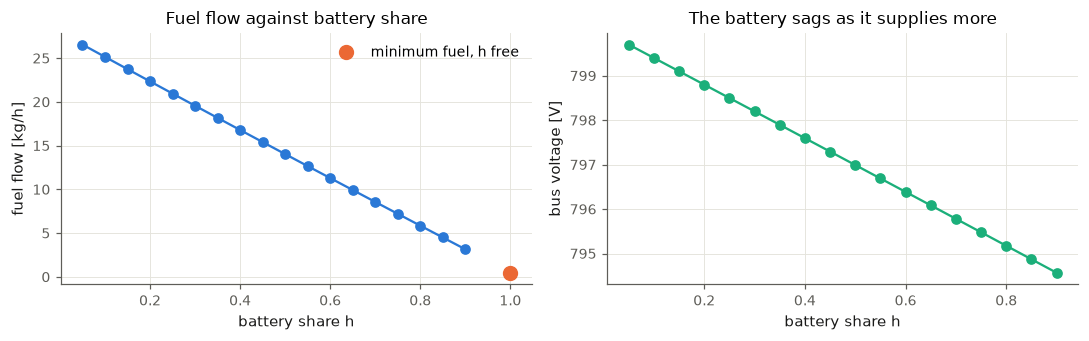

optimal share h = 1.000; infeasible shares: [0.0]
PASS  h = 0 is infeasible (the generator alone exceeds its rating)


In [5]:
shares = onp.linspace(0.0, 0.9, 19)
fuel_kg_h, voltages, feasible = [], [], []
for h in shares:
    try:
        _, sh, xh = hover_point(hybridization_electric=float(h))
        fuel_kg_h.append(sh.value(xh["engine"].fuel_flow_kg_s) * 3600)
        voltages.append(sh.value(xh["voltage_bus_V"]))
        feasible.append(True)
    except RuntimeError:
        fuel_kg_h.append(onp.nan); voltages.append(onp.nan); feasible.append(False)
_, sf, xf = hover_point(free_split=True)
h_opt = sf.value(xf["hybridization_electric"])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].plot(shares, fuel_kg_h, "o-", color=blue)
axes[0].plot(h_opt, sf.value(xf["engine"].fuel_flow_kg_s) * 3600, "o", color=orange, ms=9, label="minimum fuel, h free")
axes[0].set(xlabel="battery share h", ylabel="fuel flow [kg/h]", title="Fuel flow against battery share")
axes[1].plot(shares, voltages, "o-", color=aqua)
axes[1].set(xlabel="battery share h", ylabel="bus voltage [V]", title="The battery sags as it supplies more")
axes[0].legend(); plt.tight_layout(); plt.show()
print(f"optimal share h = {h_opt:.3f}; infeasible shares: {[round(float(h), 2) for h, ok in zip(shares, feasible) if not ok]}")
check("h = 0 is infeasible (the generator alone exceeds its rating)", not feasible[0])

Two things to read off the sweep:

- **h = 0 is infeasible.** With no battery help the generator alone would need 100.2 kW of shaft power, just above its 100 kW
  rating. IPOPT reports `Infeasible_Problem_Detected` rather than a wrong answer: the generator is undersized for this hover
  without battery assist. That is the situation the Halo is in, with fixed engines, and why its hover needs the battery.
- **Fuel falls monotonically with h**, so the free-split optimum runs to a limit.

Which limit stops it? Evaluate every inequality at the optimum:

In [6]:
pack_lim = battery_c.get_limits()
print(f"battery power {sf.value(xf['pack'].power_electric_W) / 1e3:.2f} kW of {pack_lim.max_discharge_power_W / 1e3:.0f} kW max discharge")
print(f"generator electrical power {sf.value(xf['generator'].power_electric_W) / 1e3:.3f} kW (lower bound 0)")
check("with a free split the battery is pushed to a limit", abs(sf.value(xf["pack"].power_electric_W) - pack_lim.max_discharge_power_W) < 1
      or abs(sf.value(xf["generator"].power_electric_W)) < 1)

battery power 95.92 kW of 100 kW max discharge
generator electrical power 0.000 kW (lower bound 0)
PASS  with a free split the battery is pushed to a limit


## 6. Where the same couplings live in the production flight point

`performance/flight_point.py: build_flight_point` writes the same physics for a whole aircraft, with these differences:

| Here | In `build_flight_point` |
|---|---|
| speeds prescribed | rotor speed a variable (rotor-speed physics); motor speed = gear ratio × rotor speed; generator at its peak-efficiency speed |
| actuator disk in power mode with $v_i$ as a variable | thrust known from the flight condition, so the rotor runs in thrust mode (closed form) |
| one bus power balance + battery share | two balances: battery power = $h$ × demand; generators × count = $(1 - h)$ × demand; demand includes fan power and tie losses |
| limits as plain inequalities | named, normalized operating margins from the topology (tutorial 11) |
| one motor, one generator | counts from the topology, lanes, active units in failure states |
| no aerodynamics | airplane mode: angle of attack variable, lift = weight, thrust = drag |

In [7]:
import inspect
from aircraft_closure.performance import flight_point
source = inspect.getsource(flight_point.build_flight_point)
start = source.find("    opti.subject_to([\n        (power_battery_bus_W")
print(source[start:start + 420])

    opti.subject_to([
        (power_battery_bus_W - hybridization_electric * power_electric_demand_W) / power_scale_W == 0,
        (active_generator_count * power_generator_bus_W - (1 - hybridization_electric) * power_electric_demand_W)
        / power_scale_W == 0,
        speed_motor_rad_s <= speed_motor_limit_rad_s,
    ])
    if rotor_model.speed_tip_max_m_s is not None:
        opti.subject_to(speed_rotor_rad_


## Summary

- A coupled point is a set of unknowns (torques, currents, induced velocity) and equations (momentum theory, thrust, energy split, bus
  balance); components supply expressions, the caller writes the connections.
- At fixed energy split the system is square; freeing the split adds a degree of freedom and needs an objective.
- At a single point the battery looks free; missions supply the energy accounting.

## Check yourself

<details><summary>1. Why does the example set the bus voltage equal to the battery's terminal voltage instead of making it a variable?</summary>

Without a DC/DC converter the battery terminals are on the bus, so the bus voltage is a function of the battery current (one fewer variable and equation). The topology route in tutorial 11 makes it a variable and adds the connection equality, with the same answer.
</details>

<details><summary>2. Add a second rotor string (another motor, gearbox and rotor on the same bus). How many new unknowns and equations?</summary>

Unknowns: one motor torque and one induced velocity. Equations: that rotor's momentum residual and its thrust. The bus balance gains a term. Still square at fixed share. With identical strings, the topology's `count` represents both by one set of variables (tutorial 11).
</details>

In [8]:
check_summary()

5 of 5 checks passed
